In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [2]:
df = pd.read_csv("data/student_performance_large.csv")
df.head()

,study_hours,previous_score,attendance,extra_classes,assignments_submitted,parental_support,internet_usage,sleep_hours,exam_stress,final_score
0,7,88,89,1,9,3,4,8,9,98.9
1,4,83,70,1,8,0,5,7,2,86.2
2,8,96,77,0,7,1,4,6,9,98.5
3,5,80,60,0,8,0,1,8,4,85.0
4,7,37,83,0,7,2,4,9,2,89.7


In [3]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            1000 non-null   int64  
 1   previous_score         1000 non-null   int64  
 2   attendance             1000 non-null   int64  
 3   extra_classes          1000 non-null   int64  
 4   assignments_submitted  1000 non-null   int64  
 5   parental_support       1000 non-null   int64  
 6   internet_usage         1000 non-null   int64  
 7   sleep_hours            1000 non-null   int64  
 8   exam_stress            1000 non-null   int64  
 9   final_score            1000 non-null   float64
dtypes: float64(1), int64(9)
memory usage: 78.3 KB


,study_hours,previous_score,attendance,extra_classes,assignments_submitted,parental_support,internet_usage,sleep_hours,exam_stress,final_score
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.898000,63.55000,74.903000,0.486000,5.963000,1.548000,3.007000,6.474000,4.987000,76.854900
std,2.603916,20.07218,14.331119,0.500054,2.006903,1.118457,1.402469,1.697706,2.574774,14.692747
min,1.000000,30.00000,50.000000,0.000000,3.000000,0.000000,1.000000,4.000000,1.000000,30.800000
25%,3.000000,46.00000,63.000000,0.000000,4.000000,1.000000,2.000000,5.000000,3.000000,66.000000
50%,5.000000,63.50000,75.000000,0.000000,6.000000,2.000000,3.000000,7.000000,5.000000,76.900000
75%,7.000000,81.00000,87.000000,1.000000,8.000000,3.000000,4.000000,8.000000,7.000000,88.600000
max,9.000000,99.00000,99.000000,1.000000,9.000000,3.000000,5.000000,9.000000,9.000000,100.000000


In [4]:
df.isnull().sum()


study_hours              0
previous_score           0
attendance               0
extra_classes            0
assignments_submitted    0
parental_support         0
internet_usage           0
sleep_hours              0
exam_stress              0
final_score              0
dtype: int64

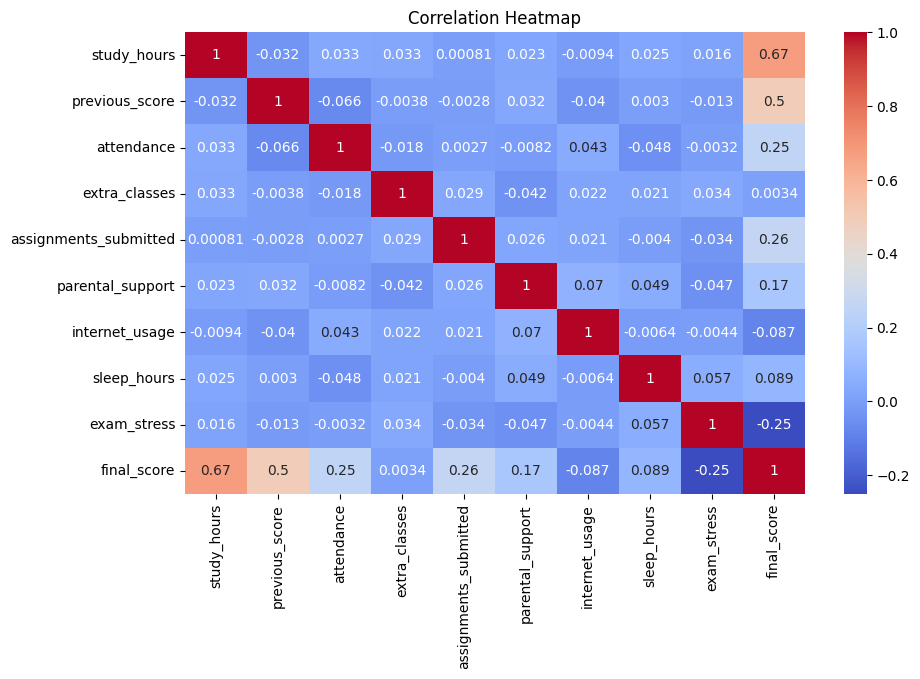

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [6]:
X = df.drop("final_score", axis=1)
y = df["final_score"]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(X_test)


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


Mean Absolute Error: 2.792684141415076
Mean Squared Error: 11.527302364777606
Root Mean Squared Error: 3.395188119203059
R² Score: 0.9507755221954612


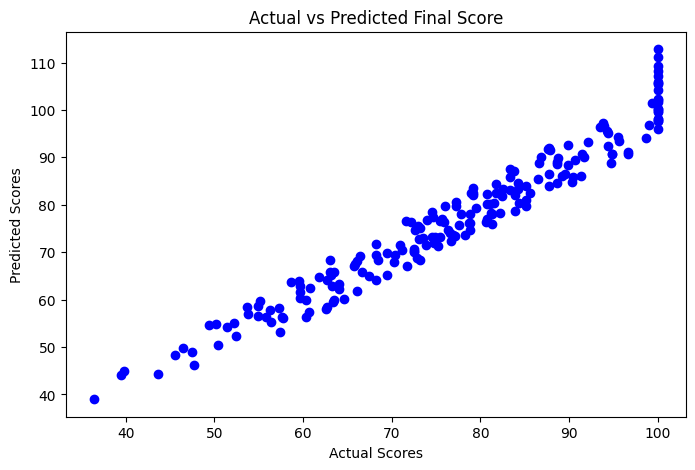

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Final Score")
plt.show()


In [12]:
sample_student = np.array([[
    8,  # study_hours
    70, # previous_score
    85, # attendance
    1,  # extra_classes
    6,  # assignments_submitted
    2,  # parental_support
    3,  # internet_usage
    7,  # sleep_hours
    5   # exam_stress
]])

pred = model.predict(sample_student)
print("Predicted Final Score:", round(pred[0], 2))


Predicted Final Score: 95.28


c:\Users\PREDATOR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
0,study_hours,3.873941
4,assignments_submitted,1.881793
5,parental_support,1.626484
7,sleep_hours,0.836612
1,previous_score,0.383794
2,attendance,0.282319
3,extra_classes,-0.322590
6,internet_usage,-0.952892
8,exam_stress,-1.398478


C:\Users\PREDATOR\AppData\Local\Temp\ipykernel_37700\780595077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance["Coefficient"], y=importance["Feature"], palette="viridis")


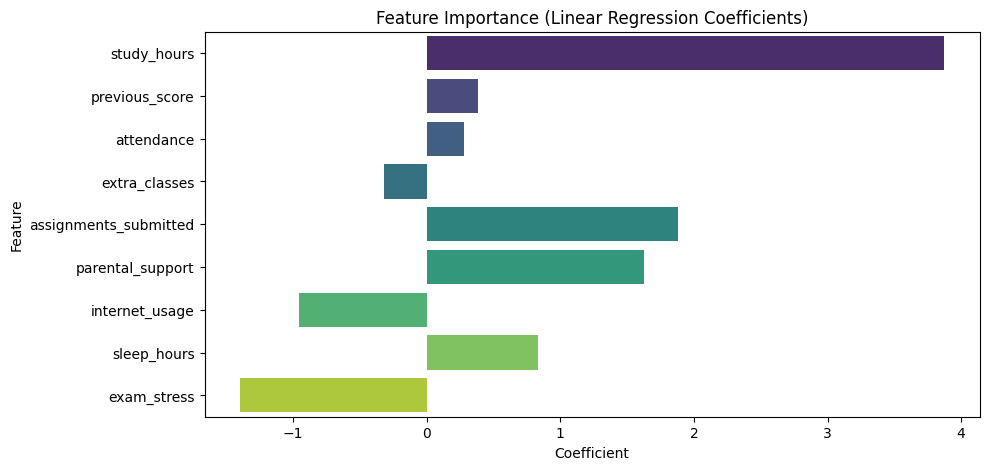

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(x=importance["Coefficient"], y=importance["Feature"], palette="viridis")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()


In [15]:
print("Model training completed successfully.")
print("Accuracy (R² Score):", r2)
print("\nThe model can now predict student final performance based on multiple factors.")


Model training completed successfully.
Accuracy (R² Score): 0.9507755221954612

The model can now predict student final performance based on multiple factors.
